In [38]:
import pyreadr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier




#carga de datos
result = pyreadr.read_r('data/listings.RData')
df = result['listings']

print("Shape inicial:", df.shape)
df.head()

Shape inicial: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


Punto 1 


In [39]:
# Limpiar price
df["price"] = df["price"].astype(str).str.replace("$", "", regex=False)
df["price"] = df["price"].str.replace(",", "", regex=False)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Eliminar SOLO NaN de price
df = df.dropna(subset=["price"])

print("Después de limpiar price:", df.shape)
print(df["price"].describe())

Después de limpiar price: (76246, 80)
count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price, dtype: float64


In [4]:
# Seleccionar variables numéricas
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Asegurar que price esté incluida
if "price" not in df_numeric.columns:
    df_numeric["price"] = df["price"]

print("Columnas:", df_numeric.columns)

Columnas: Index(['id', 'scrape_id', 'latitude', 'longitude', 'bathrooms', 'price',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'reviews_per_month'],
      dtype='str')


In [ ]:
#  Variables numéricas
df_numeric = df.select_dtypes(include=['int64', 'float64'])

# Eliminar NaN en TODO el dataset numérico 
df_model = df_numeric.dropna()

print("Shape limpio:", df_model.shape)
print("NaN totales:", df_model.isna().sum().sum())

Shape limpio: (62820, 16)
NaN totales: 0


In [6]:
# Crear df_model directamente desde df limpio
df_model = df.copy()

# Eliminar filas con cualquier NaN
df_model = df_model.dropna()

print("Shape limpio:", df_model.shape)

Shape limpio: (0, 80)


In [7]:
y = df_model["price"]
X = df_model.drop(columns=["price"])

In [8]:
# Definir variables
y = df_model["price"]

# Solo columnas numéricas para X
X = df_model.select_dtypes(include=['int64', 'float64']).drop(columns=["price"])

In [9]:
y = df_numeric["price"]
X = df_numeric.drop(columns=["price"])

In [10]:
y = df["price"]

# Variables numéricas
X = df.select_dtypes(include=['int64', 'float64']).drop(columns=["price"])



# 1. eliminar columnas con NaN problemáticos
X = X.dropna(axis=1)

# 2. rellenar NaN restantes
X = X.fillna(X.mean())

In [11]:
#normalizacion 

scaler = StandardScaler()

# Ajustar y transformar
X_scaled = scaler.fit_transform(X)

# Verificar forma
print("Shape X_scaled:", X_scaled.shape)

Shape X_scaled: (76246, 6)


In [12]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [13]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [14]:
X = X.dropna(axis=1)
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
y_pred = knn.predict(X_test)

In [16]:

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 2971.5412096292034
MAE: 536.3901377049181
R2: 0.5260039272608857


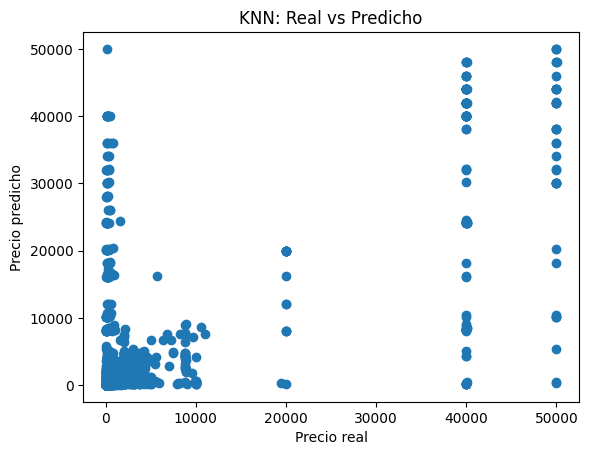

In [17]:

plt.scatter(y_test, y_pred)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("KNN: Real vs Predicho")
plt.show()

## Punto 3. Comparación del modelo KNN con modelos anteriores


In [18]:


comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Regresión lineal",
        "Árbol de regresión (depth=10)",
        "Naive Bayes",
        "KNN"
    ],
    "RMSE": [
        4297.59,
        37.43,
        4347.22,
        2971.54
    ],
    "MAE": [
        np.nan,
        np.nan,
        664.50,
        536.39
    ],
    "R2": [
        np.nan,
        np.nan,
        -0.0145,
        0.5260
    ]
})

comparacion_modelos = comparacion_modelos.sort_values("RMSE").reset_index(drop=True)
comparacion_modelos["Ranking_RMSE"] = comparacion_modelos["RMSE"].rank(method="dense")

print("Tabla comparativa de modelos de regresión:")
display(comparacion_modelos)

mejor_modelo = comparacion_modelos.iloc[0]
print(f"\nEl modelo con mejor desempeño según RMSE fue: {mejor_modelo['Modelo']} ({mejor_modelo['RMSE']:.2f})")

Tabla comparativa de modelos de regresión:


,Modelo,RMSE,MAE,R2,Ranking_RMSE
0,Árbol de regresión (depth=10),37.43,NaN,NaN,1.0
1,KNN,2971.54,536.39,0.5260,2.0
2,Regresión lineal,4297.59,NaN,NaN,3.0
3,Naive Bayes,4347.22,664.50,-0.0145,4.0



El modelo con mejor desempeño según RMSE fue: Árbol de regresión (depth=10) (37.43)


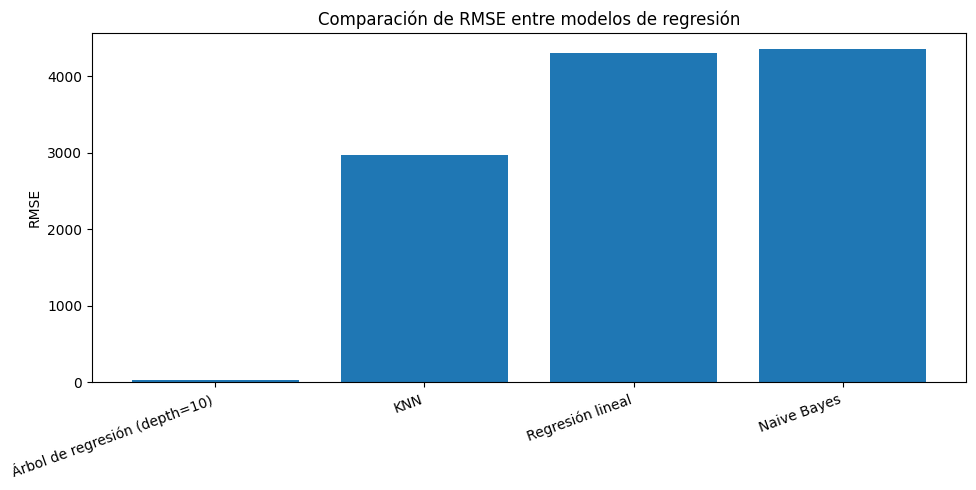

In [19]:

tabla_plot = comparacion_modelos.sort_values("RMSE", ascending=True)

plt.figure(figsize=(10,5))
plt.bar(tabla_plot["Modelo"], tabla_plot["RMSE"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("RMSE")
plt.title("Comparación de RMSE entre modelos de regresión")
plt.tight_layout()
plt.show()

Punto 4: moldelo de clasificación       

In [20]:
df["price"] = pd.to_numeric(df["price"], errors="coerce")

In [40]:
#variable categorica 
# Crear categorías de precio
df["price_category"] = pd.qcut(
    df["price"],
    q=3,
    labels=["barata", "media", "cara"],
    duplicates="drop"
)

## Punto 5. Evaluación con conjunto de prueba

### Eficiencia del algoritmo para predecir

Para evaluar la eficiencia del modelo KNN de regresión en el conjunto de prueba se utilizaron las métricas RMSE, MAE y R². Estas métricas permiten medir tanto el error promedio como la capacidad del modelo para explicar la variabilidad del precio.

In [22]:
metricas_knn_test = pd.DataFrame({
    "Métrica": ["RMSE", "MAE", "R²"],
    "Valor": [2971.54, 536.39, 0.5260]
})

print("Métricas del modelo KNN de regresión en el conjunto de prueba:")
display(metricas_knn_test)

Métricas del modelo KNN de regresión en el conjunto de prueba:


,Métrica,Valor
0,RMSE,2971.540
1,MAE,536.390
2,R²,0.526


In [23]:
print("Interpretación de resultados del KNN en prueba:")
print("- RMSE = 2971.54")
print("- MAE = 536.39")
print("- R² = 0.5260")
print("\nEsto indica que el modelo tiene un desempeño moderado.")
print("El error absoluto promedio es de aproximadamente 536 unidades monetarias.")
print("Sin embargo, el RMSE es considerablemente mayor, lo que sugiere que existen errores grandes en algunos casos.")
print("Además, el valor de R² muestra que el modelo logra explicar cerca del 52.6% de la variabilidad del precio.")

Interpretación de resultados del KNN en prueba:
- RMSE = 2971.54
- MAE = 536.39
- R² = 0.5260

Esto indica que el modelo tiene un desempeño moderado.
El error absoluto promedio es de aproximadamente 536 unidades monetarias.
Sin embargo, el RMSE es considerablemente mayor, lo que sugiere que existen errores grandes en algunos casos.
Además, el valor de R² muestra que el modelo logra explicar cerca del 52.6% de la variabilidad del precio.


In [41]:
df["price_category"] = pd.cut(
    df["price"],
    bins=3,
    labels=["barata", "media", "cara"]
)

In [42]:
print(df["price_category"].value_counts())

price_category
barata    75475
cara        712
media        59
Name: count, dtype: int64


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_class, y_class, test_size=0.2, random_state=42
)

In [45]:

knn_class = KNeighborsClassifier(n_neighbors=5)
knn_class.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [46]:
y_pred = knn_class.predict(X_test)

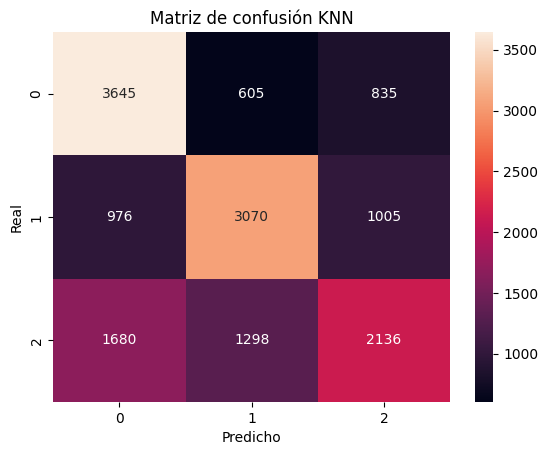

In [47]:
#matriz de confusión para KNN con categorías de precio
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusión KNN")
plt.show()